### Single kick model for 47 Young Pulsars

开始采样，包含速度误差处理，使用 200 核心...


3997it [00:47, 83.85it/s, +1000 | bound: 3 | nc: 1 | ncall: 45817 | eff(%): 11.150 | loglstar:   -inf < -32.012 <    inf | logz: -35.979 +/-  0.070 | dlogz:  0.001 >  1.009]


最终对数证据度 LogZ: -35.98


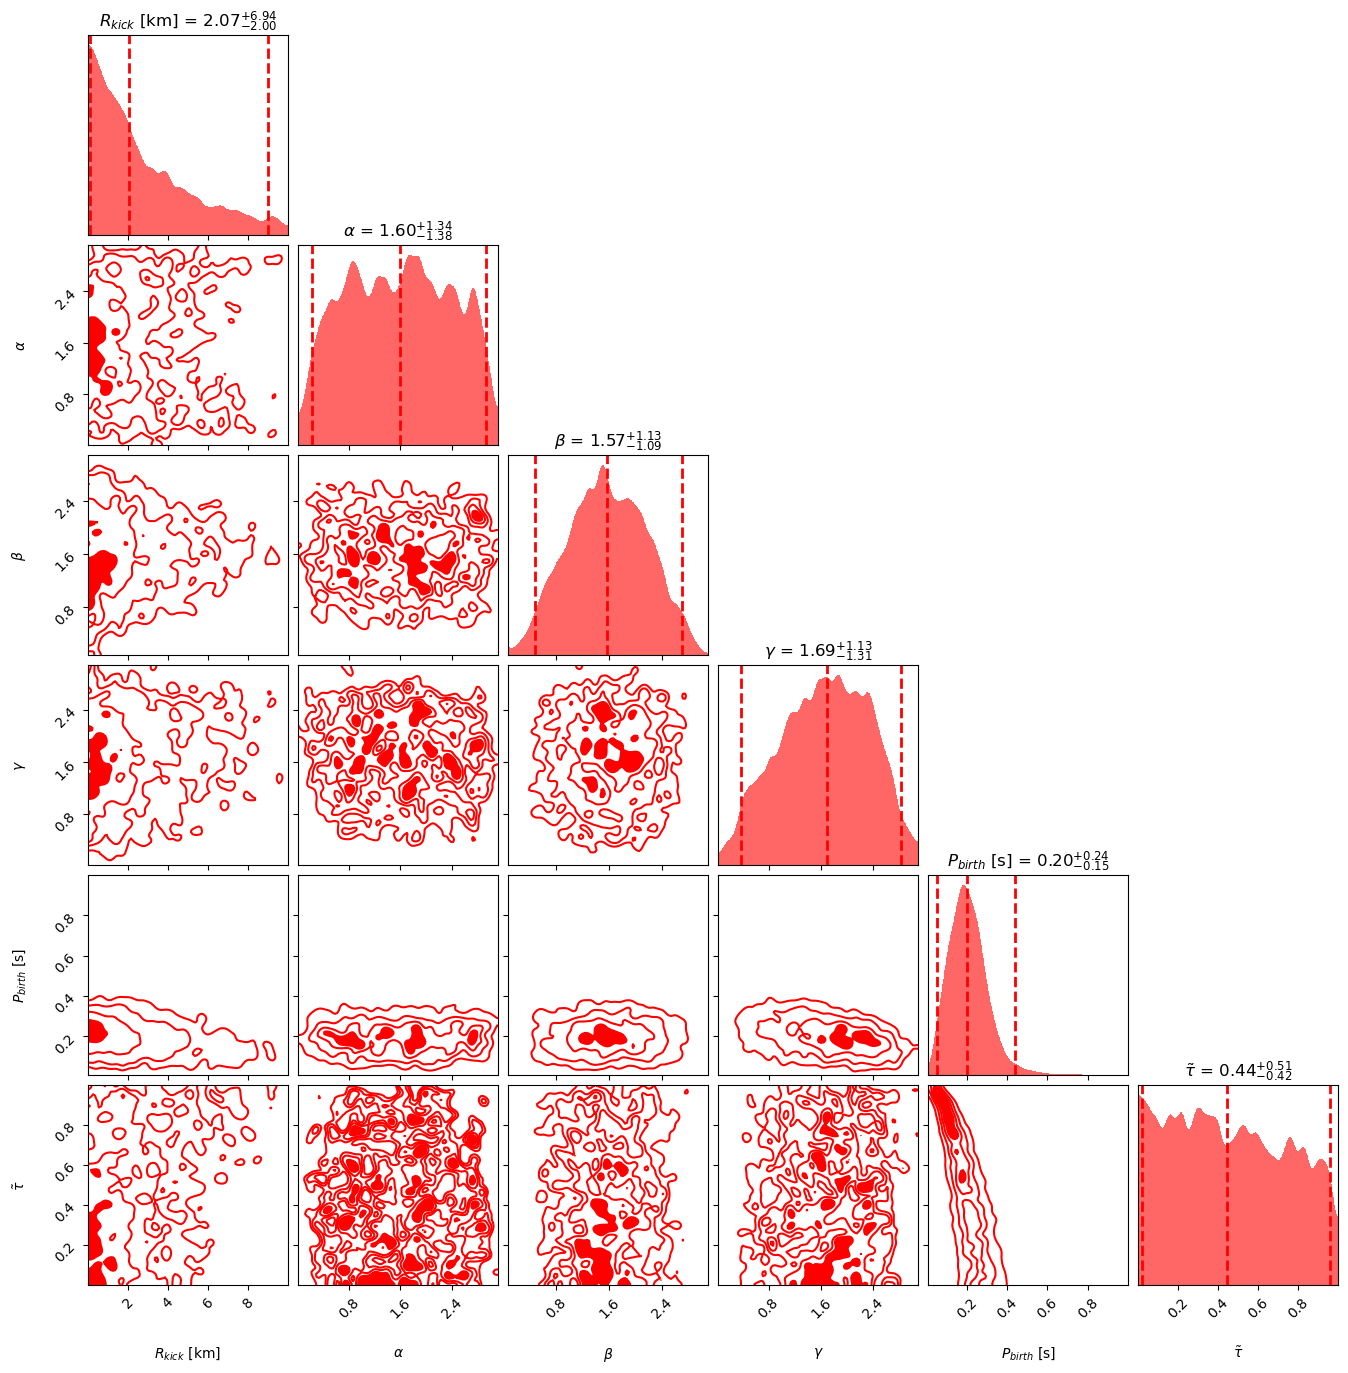

In [6]:
import numpy as np
import dynesty
from dynesty import plotting as dyplot
from multiprocessing import Pool
import contextlib
from dynesty.utils import resample_equal
# --- 1. 数据加载与筛选 ---
base_path = '/home/lz/work/pulsar_kick_period/'
v_obs_raw = np.loadtxt(base_path + 'vtrans_49_data.txt')
p_obs_raw = np.loadtxt(base_path + 'period_49_data.txt')
# 载入速度误差上限和下限 [cite: 179]
v_err_low_raw = np.loadtxt(base_path + 'v_err_low_49_data.txt')
v_err_up_raw = np.loadtxt(base_path + 'v_err_up_49_data.txt') 

# 筛选 P > 0.1s 的数据
mask = p_obs_raw > 0.1
v_obs = v_obs_raw[mask]
p_obs = p_obs_raw[mask]
v_err_low = v_err_low_raw[mask]
v_err_up = v_err_up_raw[mask]

# 物理常量 
M_NS = 1.4  # M_sun
I_NS = 50.0 # M_sun * km^2

# --- 2. 处理非对称误差的采样 (用于似然计算中的边缘化) ---
# 为每个观测点预生成速度样本云，以考虑观测不确定性
N_SAMPLES = 100 
np.random.seed(42)
v_samples_cloud = np.zeros((len(v_obs), N_SAMPLES))

for i in range(len(v_obs)):
    # 使用分段正态分布模拟非对称误差
    # 产生标准正态分布随机数，然后根据正负号缩放误差
    z = np.random.normal(0, 1, N_SAMPLES)
    v_samples_cloud[i, :] = np.where(z < 0, 
                                     v_obs[i] + z * v_err_low[i], 
                                     v_obs[i] + z * v_err_up[i])
# 确保速度为正
v_samples_cloud = np.maximum(v_samples_cloud, 1.0)

# 将数据放入全局变量，方便多核调用
GLOBAL_V_CLOUD = v_samples_cloud
GLOBAL_P_OBS = p_obs

# --- 3. 定义先验和似然 ---
def prior_transform(u):
    v = np.array(u)
    v[0] = u[0] * 10.0                 # R_kick: [0, 10] km 
    v[1] = np.arccos(1.0 - 2.0 * u[1])  # alpha (各向同性) 
    v[2] = np.arccos(1.0 - 2.0 * u[2])  # beta (各向同性) 
    v[3] = np.arccos(1.0 - 2.0 * u[3])  # gamma (各向同性) 
    v[4] = u[4] * 1.0                  # P_birth: [0, 1] s 
    v[5] = u[5] * 1.0                  # tau_tilde: [0, 1] 
    return v

def log_likelihood(theta):
    R_kick, alpha, beta, gamma, P_birth, tau_tilde = theta
    
    sb = np.sin(beta)
    if sb <= 0: return -1e30
    
    # 核心物理模型计算 [cite: 56, 62, 79]
    # 使用预生成的包含误差的速度云进行计算
    # delta_S 维度: (n_pulsars, N_SAMPLES)
    delta_S = (M_NS * R_kick * GLOBAL_V_CLOUD * np.sin(alpha)) / (I_NS * sb)
    S_birth_star = (2.0 * np.pi) / P_birth
    
    # 合成出生角速度 S0
    S0 = np.sqrt((S_birth_star + delta_S * np.cos(gamma))**2 + (delta_S * np.sin(gamma))**2)
    
    # 预测当前周期 P_pred
    P_pred = (2.0 * np.pi) / (S0 * np.sqrt(1.0 - tau_tilde))
    
    # 似然计算：考虑 10% 的模型不确定性 [cite: 94]
    sigma =  GLOBAL_P_OBS
    # 对每个观测点的采样点计算对数似然
    # 先在采样维度(axis=1)求平均，然后再对所有脉冲星求和
    logL_elements = -0.5 * ((GLOBAL_P_OBS[:, None] - P_pred) / sigma[:, None])**2 - np.log(np.sqrt(2 * np.pi) * sigma[:, None])
    
    # 通过对数空间下的平均(logsumexp)来实现边缘化速度误差
    from scipy.special import logsumexp
    logL_per_star = logsumexp(logL_elements, axis=1) - np.log(N_SAMPLES)
    
    return np.sum(logL_per_star)

# --- 4. 执行并行采样 ---
if __name__ == '__main__':
    ndim = 6
    print(f"开始采样，包含速度误差处理，使用 200 核心...")
    with Pool(processes=200) as pool:
        sampler = dynesty.NestedSampler(
            log_likelihood, 
            prior_transform, 
            ndim, 
            pool=pool, 
            queue_size=200, 
            nlive=1000
        )
        sampler.run_nested()
        results = sampler.results

    # --- 5. 绘制 Corner 图 ---
    labels = [r'$R_{kick}$ [km]', r'$\alpha$', r'$\beta$', r'$\gamma$', r'$P_{birth}$ [s]', r'$\tilde{\tau}$']
    fig, axes = dyplot.cornerplot(results, labels=labels, color='red', show_titles=True)
    fig.savefig('pulsar_corner_plot_with_errors.png')
    
    # 输出最终 LogZ [cite: 161]
    print(f"最终对数证据度 LogZ: {results.logz[-1]:.2f}")
    

In [ ]:
import pickle
# --- 提取后验样本 ---
posterior_samples = resample_equal(results.samples, np.exp(results.logwt - results.logz[-1]))

print("Posterior shape:", posterior_samples.shape)

# --- 保存为 pkl ---
with open("posterior_47_samples.pkl", "wb") as f:
    pickle.dump(posterior_samples, f)

print("Posterior samples saved to posterior_47_samples.pkl")
import pickle

with open("posterior_47_samples.pkl", "rb") as f:
    posterior_samples = pickle.load(f)

print(posterior_samples.shape)

(4969, 6)


In [7]:
N_draw = 2000
idx = np.random.choice(len(posterior_samples), N_draw)

samples = posterior_samples[idx]

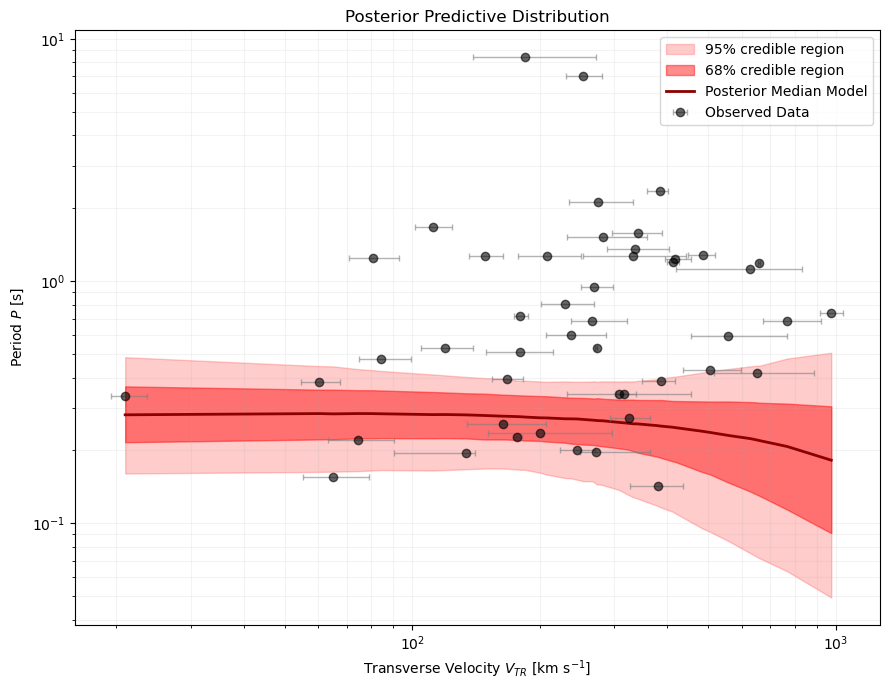

In [8]:
import matplotlib.pyplot as plt
from dynesty import utils as dyutil

# -----------------------------------------------------------
# 1. 准备误差数据
# -----------------------------------------------------------
x_errors = [v_err_low, v_err_up]

# -----------------------------------------------------------
# 2. 提取后验样本
# -----------------------------------------------------------
weights = np.exp(results.logwt - results.logz[-1])
samples = dyutil.resample_equal(results.samples, weights)

medians = np.median(samples, axis=0)

# -----------------------------------------------------------
# 3. 定义模型函数
# -----------------------------------------------------------
def generate_simulated_periods(v_data, theta):
    
    R_k, alpha, beta, gamma, Pb, tau_t = theta
    
    M = 1.4
    I = 50.0
    
    delta_S = (M * R_k * v_data * np.sin(alpha)) / (I * np.sin(beta))
    
    S_star = (2.0 * np.pi) / Pb
    
    S0 = np.sqrt((S_star + delta_S * np.cos(gamma))**2 +
                 (delta_S * np.sin(gamma))**2)
    
    p_pred = (2.0 * np.pi) / (S0 * np.sqrt(1.0 - tau_t))
    
    return p_pred


# -----------------------------------------------------------
# 4. 生成 posterior predictive curves
# -----------------------------------------------------------
n_samples = 2000
idx = np.random.choice(len(samples), n_samples)

# 对 velocity 排序（画平滑曲线）
sort_indices = np.argsort(v_obs)
v_sorted = v_obs[sort_indices]

# 保存所有曲线
P_curves = []

for i in idx:
    
    p_rand = generate_simulated_periods(v_sorted, samples[i])
    
    P_curves.append(p_rand)

P_curves = np.array(P_curves)


# -----------------------------------------------------------
# 5. 计算 credible interval
# -----------------------------------------------------------
p_median = np.median(P_curves, axis=0)

p16 = np.percentile(P_curves,16,axis=0)
p84 = np.percentile(P_curves,84,axis=0)

p2 = np.percentile(P_curves,2.5,axis=0)
p97 = np.percentile(P_curves,97.5,axis=0)


# -----------------------------------------------------------
# 6. 绘图
# -----------------------------------------------------------
plt.figure(figsize=(9,7))


# A. 观测数据
plt.errorbar(v_obs, p_obs, xerr=x_errors, fmt='o',
             color='black', ecolor='gray',
             alpha=0.6, capsize=2, elinewidth=1,
             label='Observed Data', zorder=5)


# B. 95% credible region
plt.fill_between(
    v_sorted,
    p2,
    p97,
    color='red',
    alpha=0.20,
    label='95% credible region'
)


# C. 68% credible region
plt.fill_between(
    v_sorted,
    p16,
    p84,
    color='red',
    alpha=0.45,
    label='68% credible region'
)


# D. Median model
plt.plot(
    v_sorted,
    p_median,
    color='darkred',
    lw=2,
    label='Posterior Median Model'
)


# -----------------------------------------------------------
# 7. 图像修饰
# -----------------------------------------------------------
plt.xscale('log')
plt.yscale('log')

plt.xlabel(r'Transverse Velocity $V_{TR}$ [km s$^{-1}$]')
plt.ylabel(r'Period $P$ [s]')

plt.title('Posterior Predictive Distribution')

plt.legend(loc='upper right')

plt.grid(True, which="both", ls="-", alpha=0.15)

plt.tight_layout()

plt.savefig('posterior_predictive_band.png', dpi=300)

plt.show()

### Single kick model for all 77 pulsars 

开始采样，包含速度误差处理，使用 200 核心...


4657it [06:02, 12.85it/s, +1000 | bound: 6 | nc: 1 | ncall: 68422 | eff(%):  8.390 | loglstar:   -inf < -64.001 <    inf | logz: -68.629 +/-  0.072 | dlogz:  0.001 >  1.009]


最终对数证据度 LogZ: -68.63


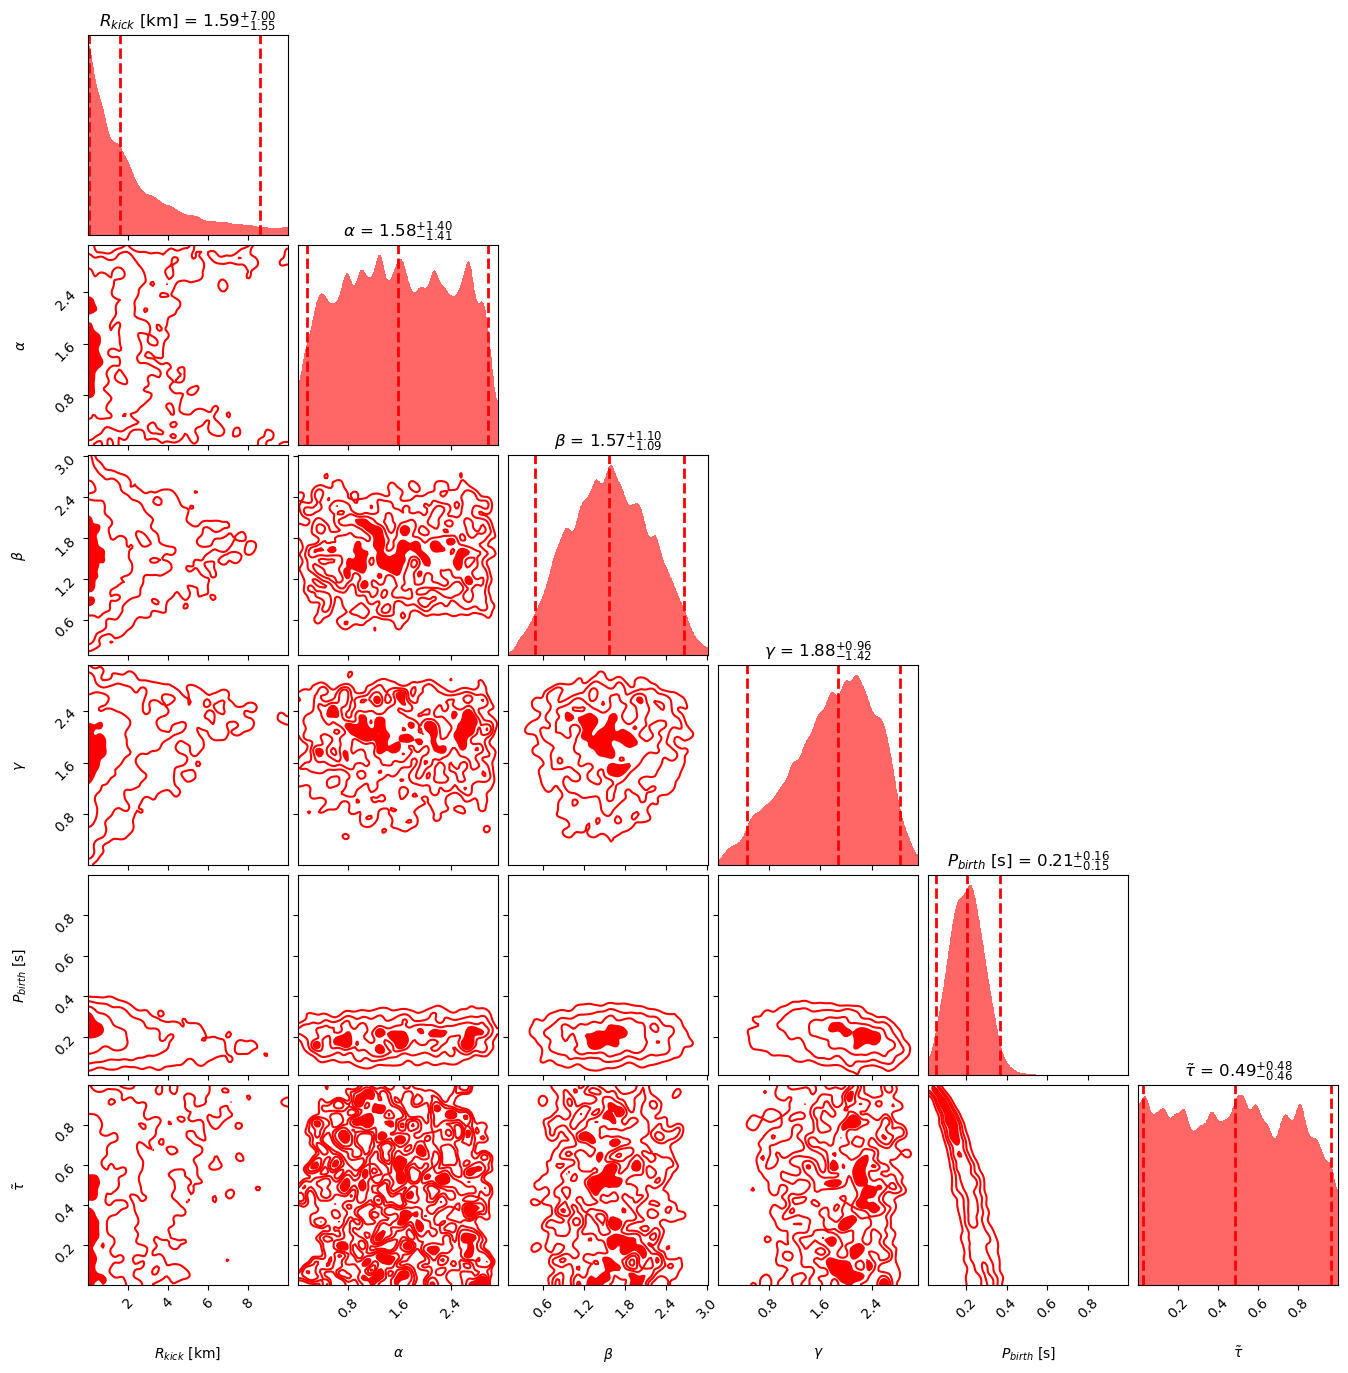

In [1]:
import numpy as np
import dynesty
from dynesty import plotting as dyplot
from multiprocessing import Pool
import contextlib

# --- 1. 数据加载与筛选 ---
base_path = '/home/lz/work/pulsar_kick_velocity/'
v_obs_raw = np.loadtxt(base_path + 'vtrans_88_data.txt')
p_obs_raw = np.loadtxt(base_path + 'period_88_data.txt')
# 载入速度误差上限和下限 [cite: 179]
v_err_low_raw = np.loadtxt(base_path + 'v_err_low_88_data.txt')
v_err_up_raw = np.loadtxt('/home/lz/work/v_err_up_88_data.txt') 

# 筛选 P > 0.1s 的数据
mask = p_obs_raw > 0.1
v_obs = v_obs_raw[mask]
p_obs = p_obs_raw[mask]
v_err_low = v_err_low_raw[mask]
v_err_up = v_err_up_raw[mask]

# 物理常量 
M_NS = 1.4  # M_sun
I_NS = 50.0 # M_sun * km^2

# --- 2. 处理非对称误差的采样 (用于似然计算中的边缘化) ---
# 为每个观测点预生成速度样本云，以考虑观测不确定性
N_SAMPLES = 50 
np.random.seed(42)
v_samples_cloud = np.zeros((len(v_obs), N_SAMPLES))

for i in range(len(v_obs)):
    # 使用分段正态分布模拟非对称误差
    # 产生标准正态分布随机数，然后根据正负号缩放误差
    z = np.random.normal(0, 1, N_SAMPLES)
    v_samples_cloud[i, :] = np.where(z < 0, 
                                     v_obs[i] + z * v_err_low[i], 
                                     v_obs[i] + z * v_err_up[i])
# 确保速度为正
v_samples_cloud = np.maximum(v_samples_cloud, 1.0)

# 将数据放入全局变量，方便多核调用
GLOBAL_V_CLOUD = v_samples_cloud
GLOBAL_P_OBS = p_obs

# --- 3. 定义先验和似然 ---
def prior_transform(u):
    v = np.array(u)
    v[0] = u[0] * 10.0                 # R_kick: [0, 10] km 
    v[1] = np.arccos(1.0 - 2.0 * u[1])  # alpha (各向同性) 
    v[2] = np.arccos(1.0 - 2.0 * u[2])  # beta (各向同性) 
    v[3] = np.arccos(1.0 - 2.0 * u[3])  # gamma (各向同性) 
    v[4] = u[4] * 1.0                  # P_birth: [0, 1] s 
    v[5] = u[5] * 1.0                  # tau_tilde: [0, 1] 
    return v

def log_likelihood(theta):
    R_kick, alpha, beta, gamma, P_birth, tau_tilde = theta
    
    sb = np.sin(beta)
    if sb <= 0: return -1e30
    
    # 核心物理模型计算 [cite: 56, 62, 79]
    # 使用预生成的包含误差的速度云进行计算
    # delta_S 维度: (n_pulsars, N_SAMPLES)
    delta_S = (M_NS * R_kick * GLOBAL_V_CLOUD * np.sin(alpha)) / (I_NS * sb)
    S_birth_star = (2.0 * np.pi) / P_birth
    
    # 合成出生角速度 S0
    S0 = np.sqrt((S_birth_star + delta_S * np.cos(gamma))**2 + (delta_S * np.sin(gamma))**2)
    
    # 预测当前周期 P_pred
    P_pred = (2.0 * np.pi) / (S0 * np.sqrt(1.0 - tau_tilde))
    
    # 似然计算：考虑 10% 的模型不确定性 [cite: 94]
    sigma =  GLOBAL_P_OBS
    # 对每个观测点的采样点计算对数似然
    # 先在采样维度(axis=1)求平均，然后再对所有脉冲星求和
    logL_elements = -0.5 * ((GLOBAL_P_OBS[:, None] - P_pred) / sigma[:, None])**2 - np.log(np.sqrt(2 * np.pi) * sigma[:, None])
    
    # 通过对数空间下的平均(logsumexp)来实现边缘化速度误差
    from scipy.special import logsumexp
    logL_per_star = logsumexp(logL_elements, axis=1) - np.log(N_SAMPLES)
    
    return np.sum(logL_per_star)

# --- 4. 执行并行采样 ---
if __name__ == '__main__':
    ndim = 6
    print(f"开始采样，包含速度误差处理，使用 200 核心...")
    with Pool(processes=200) as pool:
        sampler = dynesty.NestedSampler(
            log_likelihood, 
            prior_transform, 
            ndim, 
            pool=pool, 
            queue_size=200, 
            nlive=1000
        )
        sampler.run_nested()
        results = sampler.results

    # --- 5. 绘制 Corner 图 ---
    labels = [r'$R_{kick}$ [km]', r'$\alpha$', r'$\beta$', r'$\gamma$', r'$P_{birth}$ [s]', r'$\tilde{\tau}$']
    fig, axes = dyplot.cornerplot(results, labels=labels, color='red', show_titles=True)
    fig.savefig('pulsar_corner_plot_with_errors.png')
    
    # 输出最终 LogZ [cite: 161]
    print(f"最终对数证据度 LogZ: {results.logz[-1]:.2f}")

In [13]:
import pickle
from dynesty.utils import resample_equal

# --- 提取后验样本 ---
posterior_samples = resample_equal(results.samples, np.exp(results.logwt - results.logz[-1]))

print("Posterior shape:", posterior_samples.shape)

# --- 保存为 pkl ---
with open("posterior_samples.pkl", "wb") as f:
    pickle.dump(posterior_samples, f)

print("Posterior samples saved to posterior_samples.pkl")

NameError: name 'results' is not defined

In [15]:
def model_prediction(theta, v):
    
    R_kick, alpha, beta, gamma, P_birth, tau_tilde = theta
    
    sb = np.sin(beta)
    if sb <= 0:
        return None
    
    delta_S = (M_NS * R_kick * v * np.sin(alpha)) / (I_NS * sb)
    
    S_birth_star = (2*np.pi) / P_birth
    
    S0 = np.sqrt((S_birth_star + delta_S*np.cos(gamma))**2 +
                 (delta_S*np.sin(gamma))**2)
    
    P_pred = (2*np.pi) / (S0*np.sqrt(1 - tau_tilde))
    
    return P_pred

In [16]:
N_draw = 2000
idx = np.random.choice(len(posterior_samples), N_draw)

samples = posterior_samples[idx]

<class 'numpy.ndarray'>
(5657, 6)


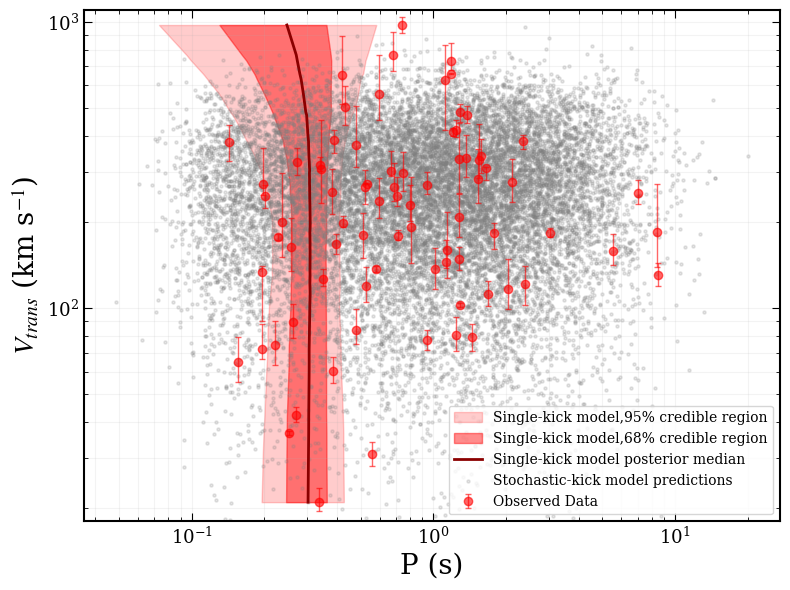

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import dynesty
from dynesty import plotting as dyplot
from multiprocessing import Pool
import contextlib

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["STIX Two Text", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "axes.labelsize": 20,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "axes.linewidth": 1.5,
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
})
# load simulated population data
data = np.loadtxt("/home/lz/work/pulsar_kick_period/sim_population.txt")

logP = data[:,0]
logV = data[:,1] - 5   # 转换成 km/s

with open("posterior_samples.pkl", "rb") as f:
    posterior_samples = pickle.load(f)

print(type(posterior_samples))
print(posterior_samples.shape)
# --- 1. 数据加载与筛选 ---
base_path = '/home/lz/work/pulsar_kick_velocity/'
v_obs_raw = np.loadtxt(base_path + 'vtrans_88_data.txt')
p_obs_raw = np.loadtxt(base_path + 'period_88_data.txt')
# 载入速度误差上限和下限 [cite: 179]
v_err_low_raw = np.loadtxt(base_path + 'v_err_low_88_data.txt')
v_err_up_raw = np.loadtxt('/home/lz/work/v_err_up_88_data.txt') 

# 筛选 P > 0.1s 的数据
mask = p_obs_raw > 0.1
v_obs = v_obs_raw[mask]
p_obs = p_obs_raw[mask]
v_err_low = v_err_low_raw[mask]
v_err_up = v_err_up_raw[mask]

# -----------------------------------------------------------
# 1. 准备误差数据
# -----------------------------------------------------------
v_errors = [v_err_low, v_err_up]

# -----------------------------------------------------------
# 2. 直接使用后验样本
# -----------------------------------------------------------
samples = posterior_samples
medians = np.median(samples, axis=0)

# -----------------------------------------------------------
# 3. 定义模型函数
# -----------------------------------------------------------
def generate_simulated_periods(v_data, theta):
    R_k, alpha, beta, gamma, Pb, tau_t = theta

    M = 1.4
    I = 50.0

    delta_S = (M * R_k * v_data * np.sin(alpha)) / (I * np.sin(beta))
    S_star = (2.0 * np.pi) / Pb

    S0 = np.sqrt((S_star + delta_S * np.cos(gamma))**2 +
                 (delta_S * np.sin(gamma))**2)

    p_pred = (2.0 * np.pi) / (S0 * np.sqrt(1.0 - tau_t))

    return p_pred

# -----------------------------------------------------------
# 4. 生成 posterior predictive curves
# -----------------------------------------------------------
n_samples = min(2000, len(samples))
idx = np.random.choice(len(samples), n_samples, replace=False)

sort_indices = np.argsort(v_obs)
v_sorted = v_obs[sort_indices]

P_curves = []

for i in idx:
    p_rand = generate_simulated_periods(v_sorted, samples[i])
    P_curves.append(p_rand)

P_curves = np.array(P_curves)

# -----------------------------------------------------------
# 5. 计算 credible interval
# -----------------------------------------------------------
p_median = np.median(P_curves, axis=0)
p16 = np.percentile(P_curves, 16, axis=0)
p84 = np.percentile(P_curves, 84, axis=0)
p2 = np.percentile(P_curves, 2.5, axis=0)
p97 = np.percentile(P_curves, 97.5, axis=0)

# -----------------------------------------------------------
# 6. 绘图
# -----------------------------------------------------------
plt.figure(figsize=(8, 6))

plt.errorbar(p_obs,v_obs, yerr=v_errors, fmt='o',
             color='red', ecolor='red',
             alpha=0.6, capsize=2, elinewidth=1,
             label='Observed Data', zorder=5)

plt.fill_betweenx(v_sorted, p2, p97,
                 color='red', alpha=0.20,
                 label='Single-kick model,95% credible region')

plt.fill_betweenx(v_sorted, p16, p84,
                 color='red', alpha=0.45,
                 label='Single-kick model,68% credible region')

plt.plot(p_median,v_sorted, 
         color='darkred', lw=2,
         label='Single-kick model posterior median')
plt.scatter(10**logP, 10**logV, s=5, alpha=0.2, c='grey',label='Stochastic-kick model predictions')
plt.xscale('log')
plt.yscale('log')
plt.ylim(18,1100)
plt.ylabel(r'$V_{trans}$ (km s$^{-1}$)')
plt.xlabel(r'P (s)')
plt.legend(loc='lower right')
plt.grid(True, which="both", ls="-", alpha=0.15)
plt.tight_layout()

plt.savefig('posterior_predictive_band.pdf', dpi=300)
plt.show()